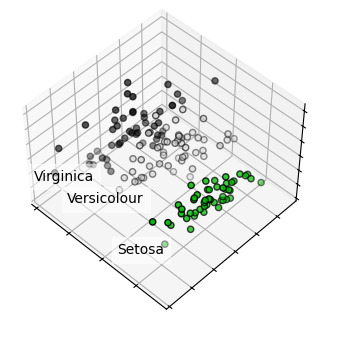

In [ ]:
# Code source: Gaël Varoquaux
# License: BSD 3 clause

import matplotlib.pyplot as plt

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401
import numpy as np

from sklearn import datasets, decomposition

np.random.seed(5)

iris = datasets.load_iris()
X = iris.data # data
y = iris.target # target labels (0, 1, 2)

fig = plt.figure(1, figsize=(4, 3))
plt.clf()

ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.set_position([0, 0, 0.95, 1])


plt.cla()
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X = pca.transform(X)

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(
        X[y == label, 0].mean(),
        X[y == label, 1].mean() + 1.5,
        X[y == label, 2].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.5, edgecolor="w", facecolor="w"),
    )
# Reorder the labels to have colors matching the cluster results
y = np.choose(y, [1, 2, 0]).astype(float)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.nipy_spectral, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

plt.show()

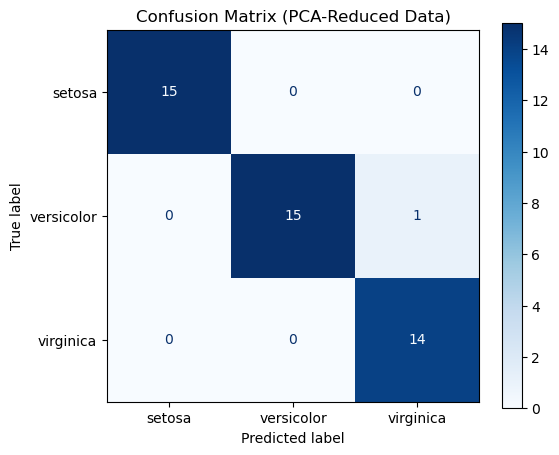

Confusion Matrix:
[[15  0  0]
 [ 0 15  1]
 [ 0  0 14]]
Silhouette Score:0.5387029014217185


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Reload original X and y to avoid the "np.choose" shuffle above
X_orig = iris.data
y_orig = iris.target 

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_orig, y_orig, test_size=0.3, random_state=5)

# 3. Apply PCA (fitting ONLY on training data to prevent data leakage)
pca_eval = decomposition.PCA(n_components=3)
X_train_pca = pca_eval.fit_transform(X_train)
X_test_pca = pca_eval.transform(X_test)

# 4. Train a classifier and predict
clf = LogisticRegression()
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

# 5. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Confusion Matrix (PCA-Reduced Data)")
plt.show()
print(f"Confusion Matrix:\n{cm}")

# 6. Calculate and print the Silhouette Score
from sklearn.metrics import silhouette_score
print(f"Silhouette Score:{silhouette_score(X_test_pca, y_pred)}")

Silhouette Score: 0.5630437008750585
Confusion Matrix:
[[36  0 14]
 [ 0 50  0]
 [ 2  0 48]]


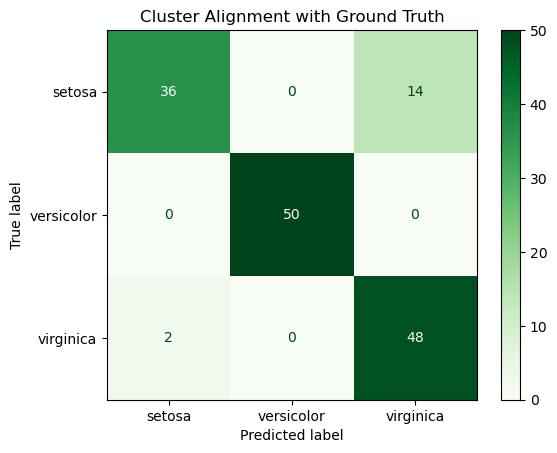

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Apply K-Means using 3 clusters (since we know there are 3 species)
# We use the X transformed by PCA from your previous code
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X)

# 2. Calculate the Silhouette Score
score = silhouette_score(X, clusters)
print(f"Silhouette Score: {score}")

# 3. The "Alignment" Problem
# K-Means doesn't know '0' means Setosa. It might call Setosa '1'.
# We map the cluster labels to the actual species labels for the matrix.
import scipy.stats as stats
labels = np.zeros_like(clusters)
for i in range(3):
    mask = (clusters == i)
    labels[mask] = stats.mode(y[mask], keepdims=True)[0]

# 4. Confusion Matrix (Clustering vs. Actual Labels)
cm = confusion_matrix(y, labels)
print(f"Confusion Matrix:\n{cm}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Greens')
plt.title("Cluster Alignment with Ground Truth")
plt.show()